# Пример с прогнозированием целевой переменной

**Целевая переменная**: callcard

**Признаки**: retire, gender, reside, region, age, tenure, income, wireless.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [13]:
df = pd.read_excel('c2.xls')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,equipmon,cardmon,wiremon,multline,voice,internet,callid,callwait,forward,confer
0,Zone 2,13,44,Married,9,64,College degree,5,No,Male,...,0.0,7.50,0.0,No,No,No,No,No,Yes,No
1,Zone 3,11,33,Married,7,136,Post-undergraduate degree,5,No,Male,...,0.0,15.25,35.7,No,Yes,No,Yes,Yes,Yes,Yes
2,Zone 3,68,52,Married,24,116,Did not complete high school,29,No,Female,...,0.0,30.25,0.0,No,No,No,Yes,Yes,No,Yes
3,Zone 2,33,33,Unmarried,12,33,High school degree,0,No,Female,...,0.0,0.00,0.0,No,No,No,No,No,No,No
4,Zone 2,23,30,Married,9,30,Did not complete high school,2,No,Male,...,0.0,0.00,0.0,No,No,No,Yes,No,Yes,Yes


In [30]:
features = ['retire', 'gender', 'reside', 'region', 'age', 'tenure', 'income', 'wireless']
target = 'callcard'

Создаем копию данных и исследуем пропуски

In [17]:
df_model = df[features + [target]].copy()

print(f"Пропуски до обработки:\n{df_model.isnull().sum()}")

Пропуски до обработки:
retire      0
gender      0
reside      0
region      0
age         0
tenure      0
income      0
wireless    0
callcard    0
dtype: int64


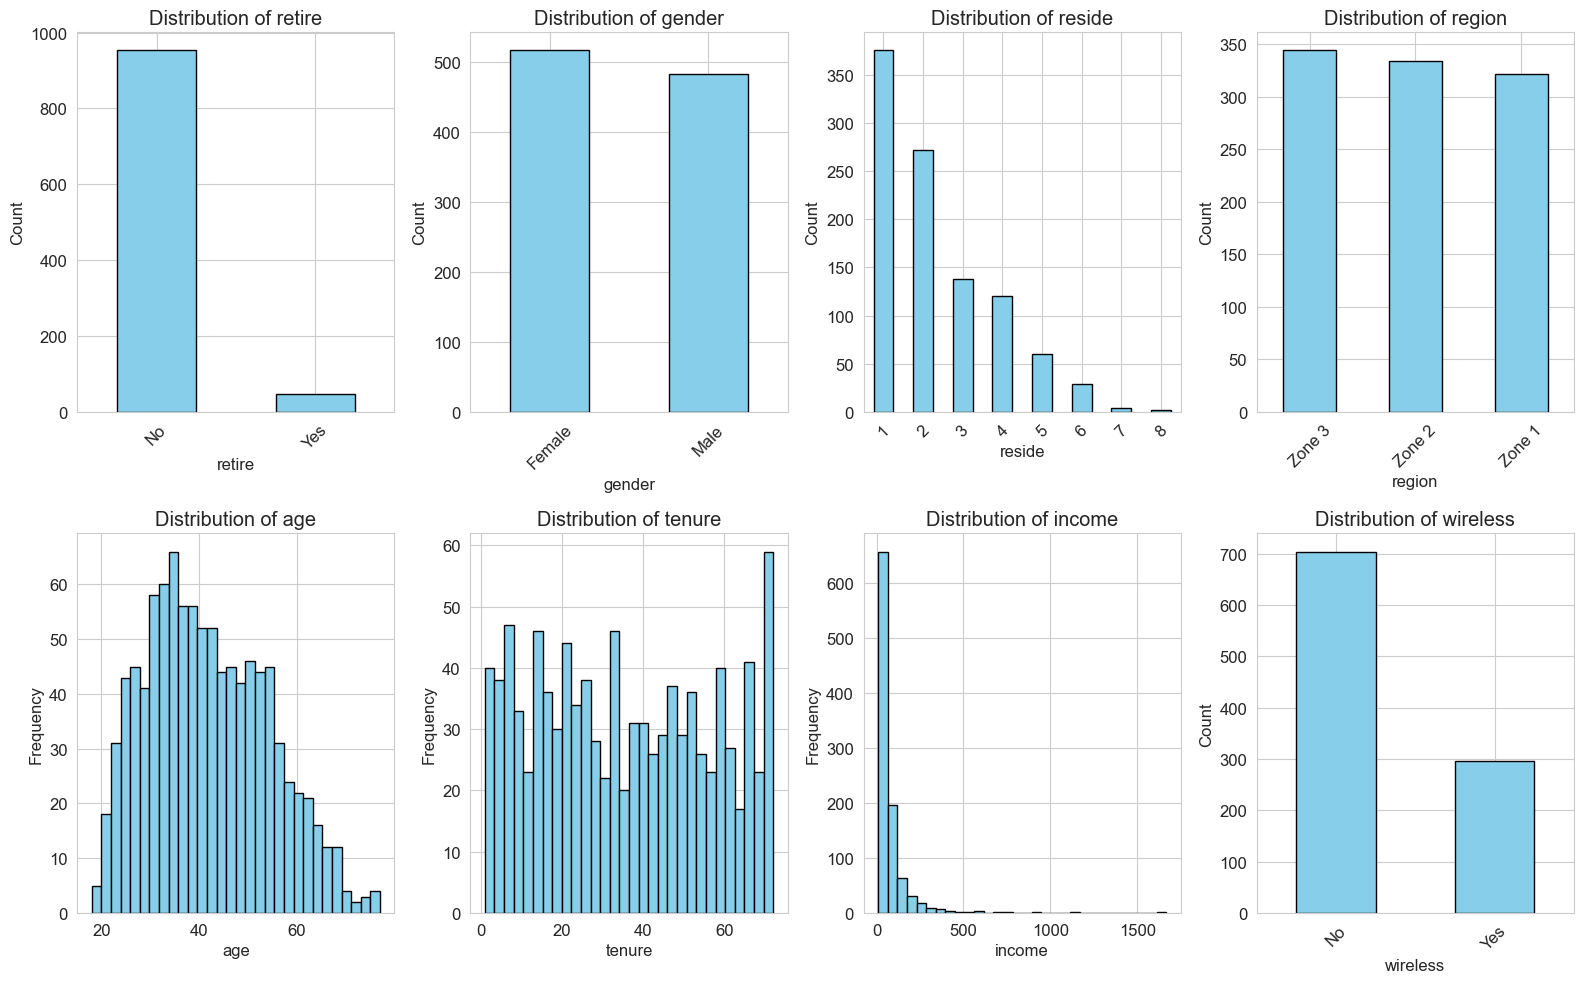

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    if df[col].dtype == 'object' or df[col].nunique() < 10:
        # Категориальный признак - bar plot
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        # Числовой признак - гистограмма
        axes[i].hist(df[col], bins=30, edgecolor='black', color='skyblue')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Интерпретация данных:
1. Большинство пользователей не на пенсии
2. Среди пользователей поровну мужчин и женщин
3. Преобладает 1-2 человека на домохозяйство среди клиентов
4. Примерно поровну пользователей в разных зонах региона
5. Нормальное распределение пользователей по возрасту с преимуществом возрастной группы ориентировочно 30-50
6. Ненормальное распределение количество месяцев пользования услугами
7. У большинства пользователей доход указан как 0
8. У большинства пользователей нет беспроводной сети дома

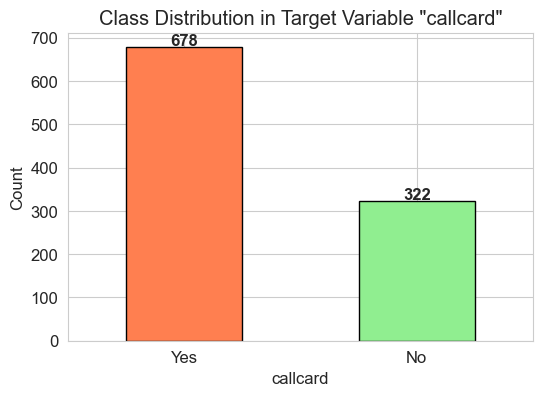

In [32]:
plt.figure(figsize=(6, 4))
df[target].value_counts().plot(kind='bar', color=['coral', 'lightgreen'], edgecolor='black')
plt.title(f'Class Distribution in Target Variable "{target}"')
plt.xlabel(target)
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(df[target].value_counts().values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

В выборке из 1000 клиентов около 68% пользуются телефонной картой как услугой. Дисбаланс классов умеренный, но для надежности используем class_weight_balanced

Создаем копию данных для кодирования и кодируем признаки. Смотрим корреляцию между признаками и целевым показателем.

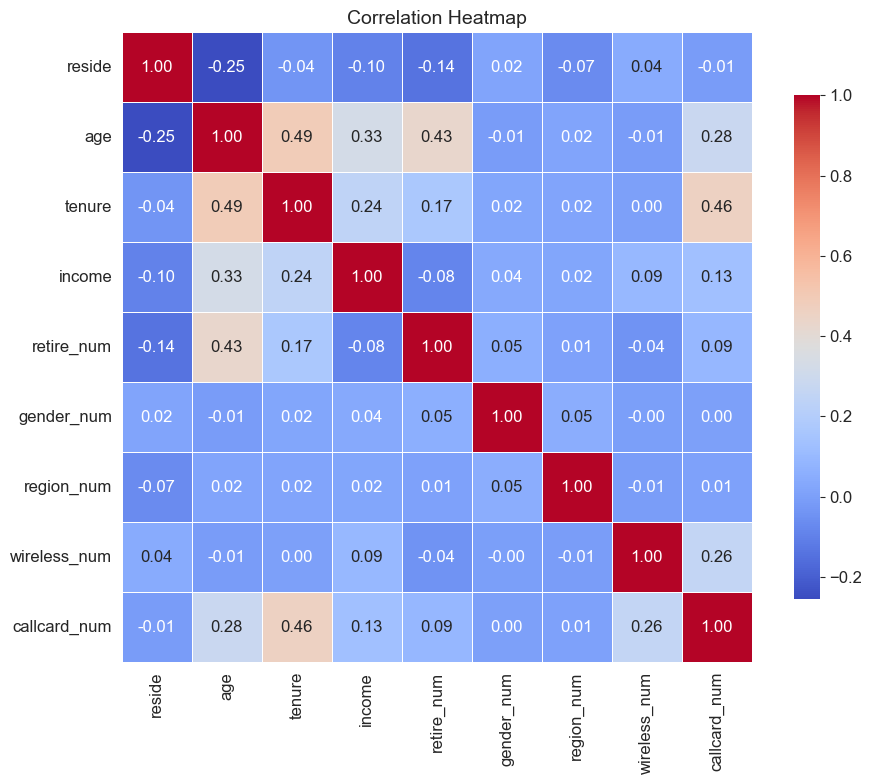

In [100]:
df_corr = df.copy()

df_corr['retire_num'] = df_corr['retire'].map({'No': 0, 'Yes': 1})
df_corr['gender_num'] = df_corr['gender'].map({'Male': 0, 'Female': 1})

le = LabelEncoder()
df_corr['region_num'] = le.fit_transform(df_corr['region'])
df_corr['wireless_num'] = df_corr['wireless'].map({'No': 0, 'Yes': 1})

if df_corr[target].dtype == 'object':
    df_corr['callcard_num'] = df_corr[target].map({'No': 0, 'Yes': 1})
    target_num = 'callcard_num'
else:
    target_num = target

corr_cols = ['reside', 'age', 'tenure', 'income', 
             'retire_num', 'gender_num', 'region_num', 'wireless_num', target_num]

corr_cols = [col for col in corr_cols if col in df_corr.columns]

plt.figure(figsize=(10, 8))
corr_matrix = df_corr[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

Есть умеренная положительная корреляция между: 

age и tenure (0.49). Чем старше клиент, тем дольше он пользуется услугами компании. Логично: пожилые клиенты имеют больший стаж.

tenure и callcard (0.46). Чем дольше пользуется клиент услугами компании, тем вероятнее пользуется телефонной картой.

age и retire (0.43). Чем выше возраст, тем выше шанс быть на пенсии.

     Feature      VIF
      reside 2.909586
         age 9.004196
      tenure 5.061397
      income 1.825839
wireless_num 1.415559
  retire_num 1.269780
  gender_num 1.989210
  region_num 2.400079


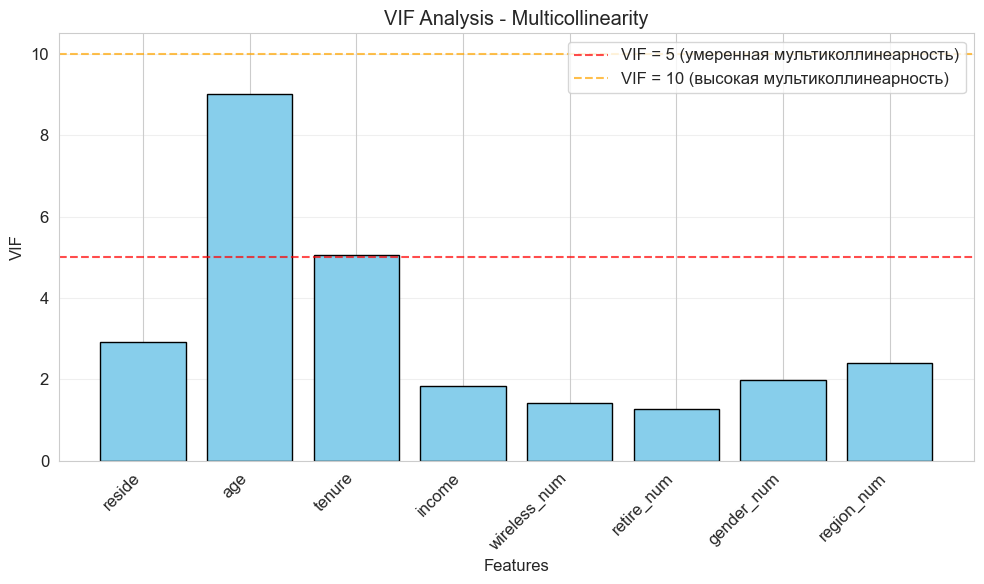

In [95]:
vif_cols = ['reside', 'age', 'tenure', 'income', 'wireless_num', 'retire_num', 'gender_num', 'region_num']
vif_cols = [col for col in vif_cols if col in df_corr.columns]

if len(vif_cols) < 2:
    print("Недостаточно признаков для VIF анализа")
else:
    vif_data = pd.DataFrame()
    vif_data["Feature"] = vif_cols
    vif_data["VIF"] = [variance_inflation_factor(df_corr[vif_cols].values, i) 
                       for i in range(len(vif_cols))]
    
    print(vif_data.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(vif_data['Feature'], vif_data['VIF'], color='skyblue', edgecolor='black')
    plt.axhline(y=5, color='red', linestyle='--', label='VIF = 5 (умеренная мультиколлинеарность)', alpha=0.7)
    plt.axhline(y=10, color='orange', linestyle='--', label='VIF = 10 (высокая мультиколлинеарность)', alpha=0.7)
    plt.ylabel('VIF')
    plt.xlabel('Features')
    plt.title('VIF Analysis - Multicollinearity')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Влияющей на построение моделей мультиколлинеарности между признаками нет.

In [185]:
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

Настройка выборок test/train

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nРазмер выборок:")
print(f"  Обучающая выборка: {X_train.shape[0]} строк ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  Тестовая выборка:  {X_test.shape[0]} строк ({X_test.shape[0]/len(df)*100:.1f}%)")


Размер выборок:
  Обучающая выборка: 750 строк (75.0%)
  Тестовая выборка:  250 строк (25.0%)


In [184]:
print(f"\nРаспределение целевой переменной:")
print(f"  Обучающая выборка - Yes: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Обучающая выборка - No:  {(len(y_train)-y_train.sum())} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Тестовая выборка - Yes:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Тестовая выборка - No:   {(len(y_test)-y_test.sum())} ({(1-y_test.mean())*100:.1f}%)")


Распределение целевой переменной:
  Обучающая выборка - Yes: 509 (67.9%)
  Обучающая выборка - No:  241 (32.1%)
  Тестовая выборка - Yes:  169 (67.6%)
  Тестовая выборка - No:   81 (32.4%)


Стандартизируем признаки

In [97]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучаем модель с учетом дисбаланса

In [98]:
log_reg = LogisticRegression(
    random_state=42, 
    max_iter=1000, 
    class_weight='balanced',
    solver='lbfgs'
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [99]:
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)
y_train_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"  Intercept (свободный член): {log_reg.intercept_[0]:.4f}")
print(f"  Количество признаков: {len(log_reg.coef_[0])}")

  Intercept (свободный член): 0.4096
  Количество признаков: 9


Модель может предсказать наличие услуги телефонной карточки с вероятностью 60%. Это примерно соотносится с реальным показателем наличия услуги у пользователей в данных (68%).

In [183]:
def calculate_metrics(y_true, y_pred, y_proba, dataset_name):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }
    return metrics

train_metrics = calculate_metrics(y_train, y_train_pred, y_train_proba, "Обучающая")
test_metrics = calculate_metrics(y_test, y_test_pred, y_test_proba, "Тестовая")

print(" " * 60)
print(f"{'Метрика':<12} {'Обучающая выборка':<20} {'Тестовая выборка':<20} {'Разница':<10}")
print(" " * 60)

for metric in train_metrics.keys():
    train_val = train_metrics[metric]
    test_val = test_metrics[metric]
    diff = abs(train_val - test_val)
    print(f"{metric:<12} {train_val:<20.4f} {test_val:<20.4f} {diff:<10.4f}")

print(" " * 60)

print("\n  Полный отчет классификации (тестовая выборка)  ")
print(classification_report(y_test, y_test_pred, target_names=['No callcard', 'Yes callcard']))

                                                            
Метрика      Обучающая выборка    Тестовая выборка     Разница   
                                                            
Accuracy     0.7680               0.7360               0.0320    
Precision    0.8886               0.8759               0.0127    
Recall       0.7525               0.7101               0.0424    
F1-score     0.8149               0.7843               0.0306    
ROC-AUC      0.8396               0.8334               0.0061    
                                                            

  Полный отчет классификации (тестовая выборка)  
              precision    recall  f1-score   support

 No callcard       0.57      0.79      0.66        81
Yes callcard       0.88      0.71      0.78       169

    accuracy                           0.74       250
   macro avg       0.72      0.75      0.72       250
weighted avg       0.78      0.74      0.74       250



Модель правильно предсказывает использование услуги телефонной карты по 74 из 100 пользователей.
Из 100 предсказанных услугу купят примерно 88 пользователей.

Показатель ROC-AUC 0.83 достаточно высокий и указывает на достаточно хорошее качество работы модели.

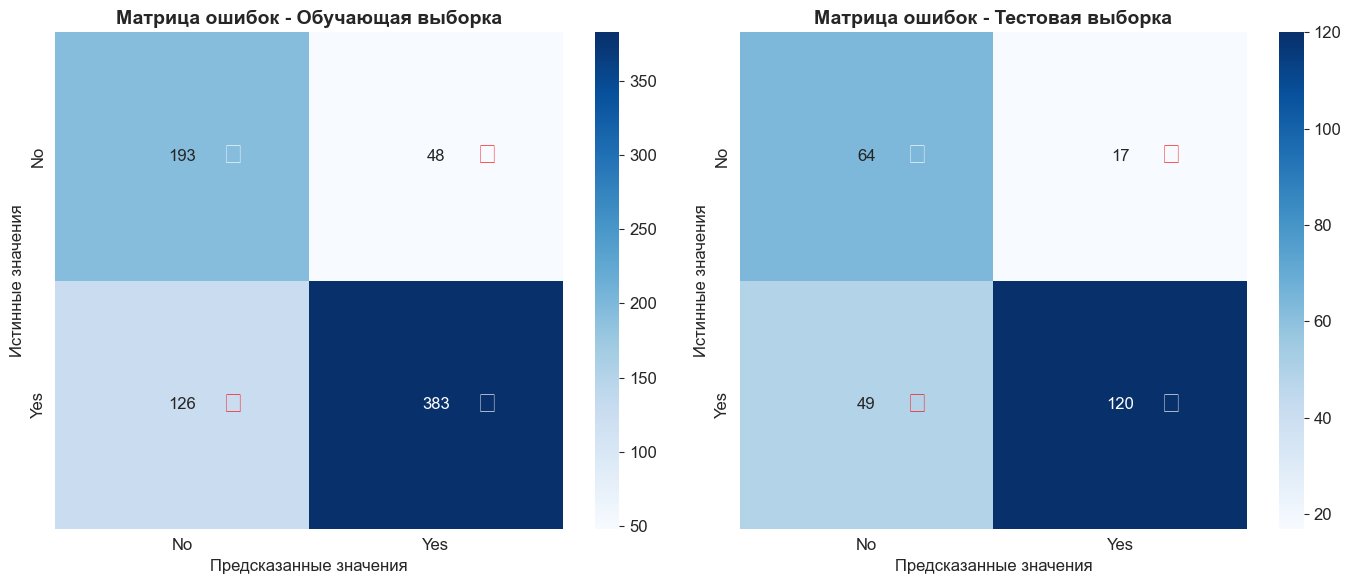

In [107]:
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('Матрица ошибок - Обучающая выборка', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Предсказанные значения', fontsize=12)
axes[0].set_ylabel('Истинные значения', fontsize=12)

for i in range(2):
    for j in range(2):
        if i == j:
            axes[0].text(j+0.7, i+0.5, '✓', ha='center', va='center', fontsize=20, color='white' if cm_train[i,j] > cm_train.max()/2 else 'green')
        else:
            axes[0].text(j+0.7, i+0.5, '✗', ha='center', va='center', fontsize=20, color='red')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('Матрица ошибок - Тестовая выборка', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Предсказанные значения', fontsize=12)
axes[1].set_ylabel('Истинные значения', fontsize=12)

for i in range(2):
    for j in range(2):
        if i == j:
            axes[1].text(j+0.7, i+0.5, '✓', ha='center', va='center', fontsize=20, color='white' if cm_test[i,j] > cm_test.max()/2 else 'green')
        else:
            axes[1].text(j+0.7, i+0.5, '✗', ha='center', va='center', fontsize=20, color='red')

plt.tight_layout()
plt.show()

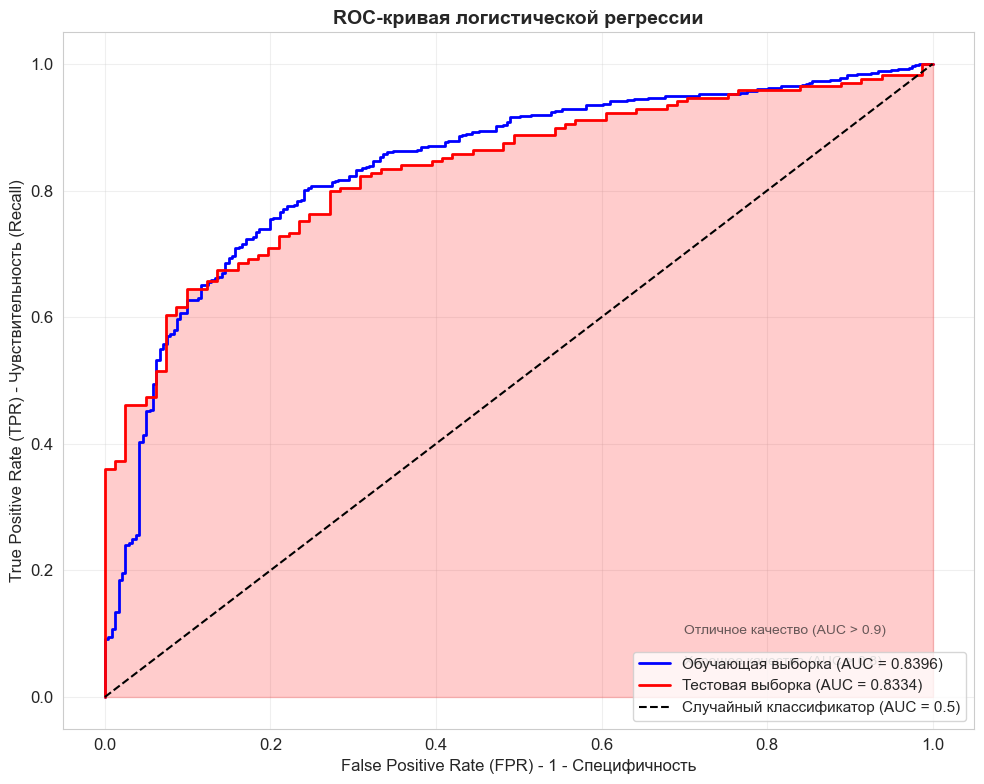

In [109]:
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)

roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(10, 8))

plt.plot(fpr_train, tpr_train, 
         label=f'Обучающая выборка (AUC = {roc_auc_train:.4f})', 
         linewidth=2, color='blue')
plt.plot(fpr_test, tpr_test, 
         label=f'Тестовая выборка (AUC = {roc_auc_test:.4f})', 
         linewidth=2, color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)', linewidth=1.5)

plt.fill_between(fpr_test, tpr_test, alpha=0.2, color='red')
plt.xlabel('False Positive Rate (FPR) - 1 - Специфичность', fontsize=12)
plt.ylabel('True Positive Rate (TPR) - Чувствительность (Recall)', fontsize=12)
plt.title('ROC-кривая логистической регрессии', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.annotate(f'Отличное качество (AUC > 0.9)', xy=(0.7, 0.1), fontsize=10, alpha=0.7)
plt.annotate(f'Хорошее качество (AUC > 0.8)', xy=(0.7, 0.05), fontsize=10, alpha=0.7)

plt.tight_layout()
plt.show()

ROC-AUC по обеим выборкам достаточно высокий и говорит о хорошем качестве модели. Отличия в показателе минимальны между выборками.

Проведем кросс-валидацию с 5 фолдами.


 5-fold кросс-валидация 
                                                            
Метрика      Среднее      Ст. отклонение  Мин        Макс      
                                                            
Accuracy     0.7490       0.0128          0.7250     0.7600    
Precision    0.8715       0.0079          0.8607     0.8829    
Recall       0.7389       0.0234          0.7059     0.7721    
F1-score     0.7995       0.0130          0.7773     0.8140    
ROC-AUC      0.8292       0.0196          0.8122     0.8660    
                                                            


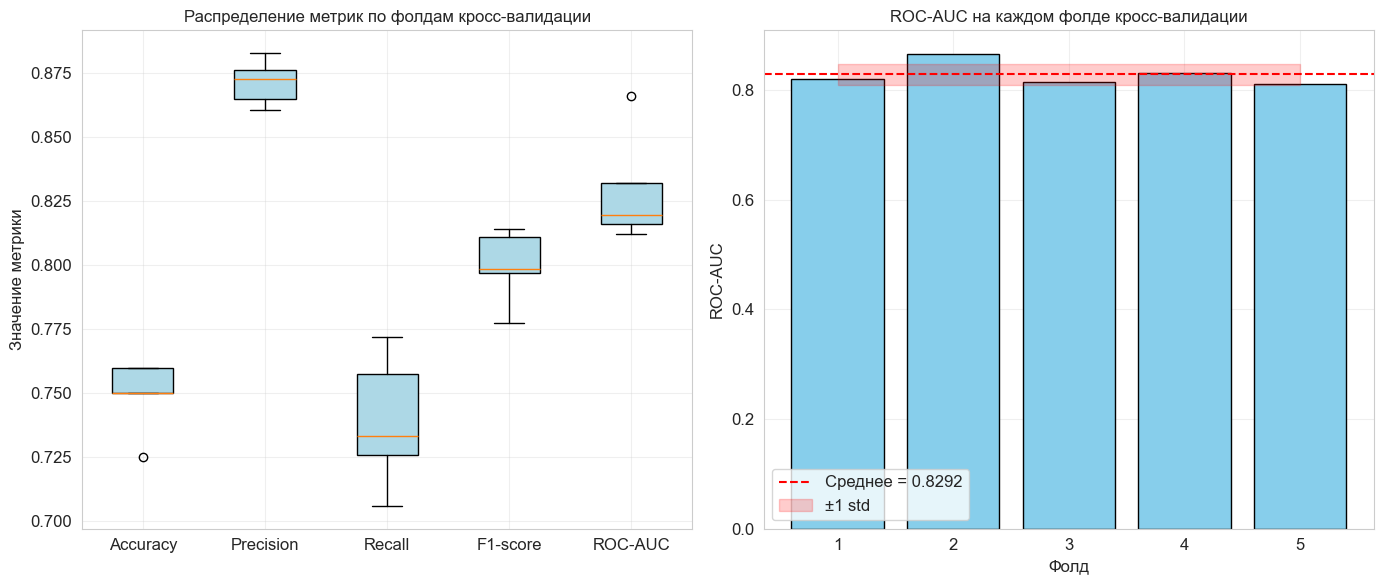

In [182]:
scaler_cv = StandardScaler()
X_scaled_all = scaler_cv.fit_transform(X)

cv_folds = 5
cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(log_reg, X_scaled_all, y, cv=cv_strategy, scoring='accuracy')
cv_precision = cross_val_score(log_reg, X_scaled_all, y, cv=cv_strategy, scoring='precision')
cv_recall = cross_val_score(log_reg, X_scaled_all, y, cv=cv_strategy, scoring='recall')
cv_f1 = cross_val_score(log_reg, X_scaled_all, y, cv=cv_strategy, scoring='f1')
cv_roc_auc = cross_val_score(log_reg, X_scaled_all, y, cv=cv_strategy, scoring='roc_auc')

print(f"\n {cv_folds}-fold кросс-валидация ")
print(" " * 60)
print(f"{'Метрика':<12} {'Среднее':<12} {'Ст. отклонение':<15} {'Мин':<10} {'Макс':<10}")
print(" " * 60)
print(f"{'Accuracy':<12} {cv_accuracy.mean():<12.4f} {cv_accuracy.std():<15.4f} {cv_accuracy.min():<10.4f} {cv_accuracy.max():<10.4f}")
print(f"{'Precision':<12} {cv_precision.mean():<12.4f} {cv_precision.std():<15.4f} {cv_precision.min():<10.4f} {cv_precision.max():<10.4f}")
print(f"{'Recall':<12} {cv_recall.mean():<12.4f} {cv_recall.std():<15.4f} {cv_recall.min():<10.4f} {cv_recall.max():<10.4f}")
print(f"{'F1-score':<12} {cv_f1.mean():<12.4f} {cv_f1.std():<15.4f} {cv_f1.min():<10.4f} {cv_f1.max():<10.4f}")
print(f"{'ROC-AUC':<12} {cv_roc_auc.mean():<12.4f} {cv_roc_auc.std():<15.4f} {cv_roc_auc.min():<10.4f} {cv_roc_auc.max():<10.4f}")
print(" " * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics_data = [cv_accuracy, cv_precision, cv_recall, cv_f1, cv_roc_auc]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

bp = axes[0].boxplot(metrics_data, labels=metrics_names, patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor('lightblue')
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].set_title('Распределение метрик по фолдам кросс-валидации', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, cv_folds+1), cv_roc_auc, color='skyblue', edgecolor='black')
axes[1].axhline(y=cv_roc_auc.mean(), color='red', linestyle='--', label=f'Среднее = {cv_roc_auc.mean():.4f}')
axes[1].fill_between(range(1, cv_folds+1), 
                      cv_roc_auc.mean() - cv_roc_auc.std(), 
                      cv_roc_auc.mean() + cv_roc_auc.std(), 
                      alpha=0.2, color='red', label='±1 std')
axes[1].set_xlabel('Фолд', fontsize=12)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_title('ROC-AUC на каждом фолде кросс-валидации', fontsize=12)
axes[1].set_xticks(range(1, cv_folds+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модель стабильна, результаты почти не меняются на разных подвыборках данных. По всем показателям качества незначительное отклонение. У модели нет сильной привязки к конкретному разбиению, отсутствует переобучение.

Проинтерпретируем коэффициенты модели через Odds Ratios.

In [180]:
coefficients = log_reg.coef_[0]
intercept = log_reg.intercept_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент (β)': coefficients,
    'Odds Ratio (exp(β))': np.exp(coefficients)
})

coef_df = coef_df.sort_values('Odds Ratio (exp(β))', ascending=False)

print(f"{'Признак':<25} {'Odds Ratio':<15}")
print(" " * 60)

for _, row in coef_df.iterrows():
    print(f"{row['Признак']:<25} {row['Odds Ratio (exp(β))']:<15.4f}")

Признак                   Odds Ratio     
                                                            
tenure                    3.5315         
wireless_encoded          2.2637         
retire_encoded            1.1947         
age                       1.1879         
reside                    1.1235         
gender_encoded            0.9927         
income                    0.9697         
region_Zone 2             0.9595         
region_Zone 3             0.9541         


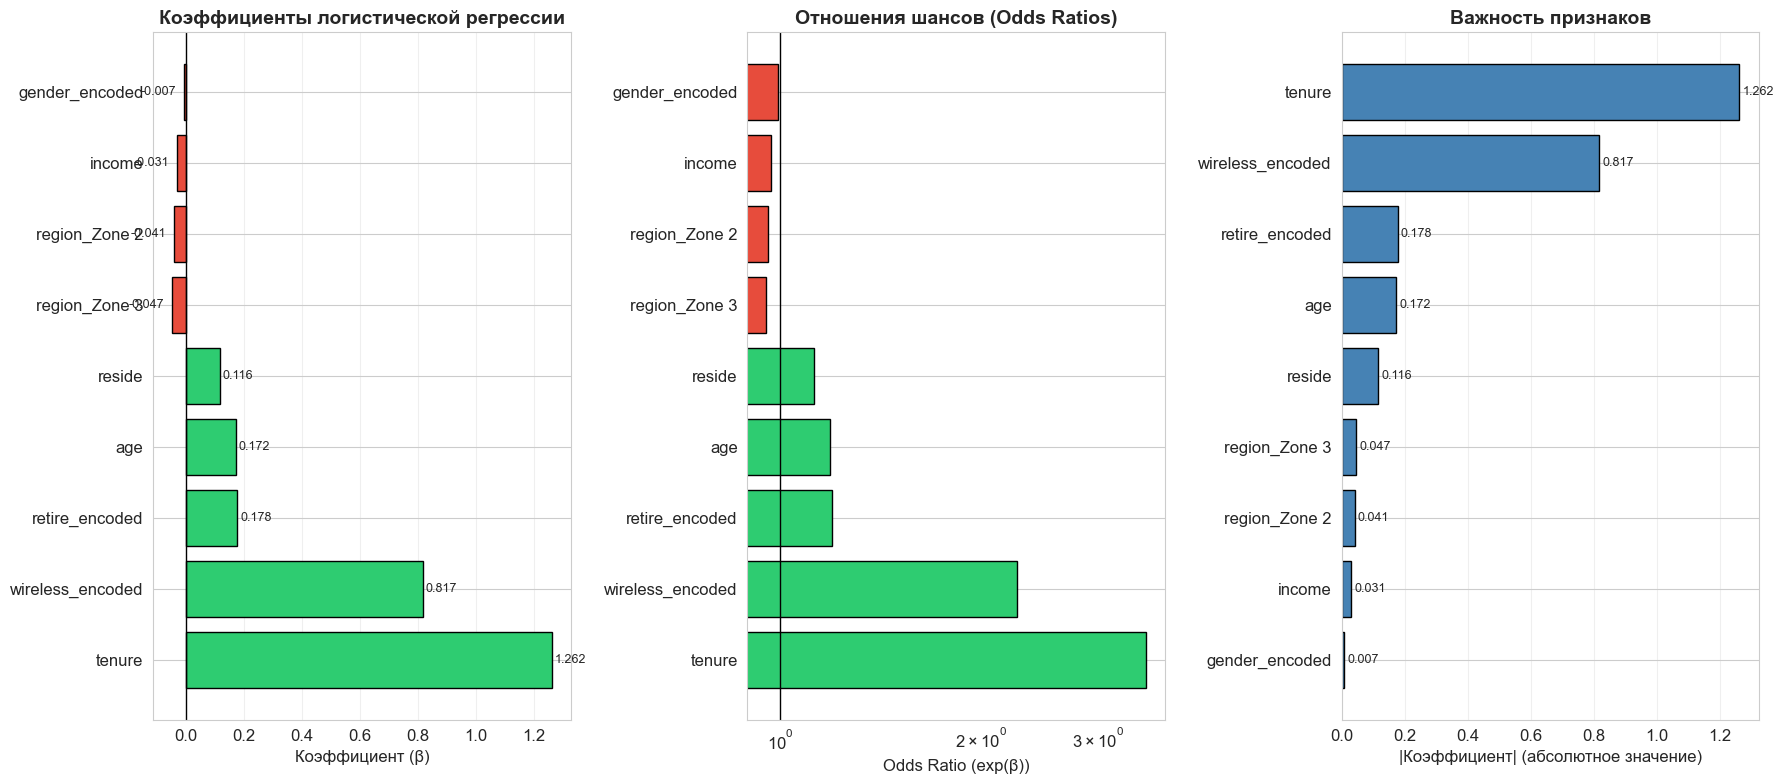

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_df['Коэффициент (β)']]
axes[0].barh(coef_df['Признак'], coef_df['Коэффициент (β)'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Коэффициент (β)', fontsize=12)
axes[0].set_title('Коэффициенты логистической регрессии', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(coef_df.iterrows()):
    axes[0].text(row['Коэффициент (β)'] + (0.01 if row['Коэффициент (β)'] >= 0 else -0.15), 
                 i, f"{row['Коэффициент (β)']:.3f}", va='center', fontsize=9)

colors_or = ['#2ecc71' if x > 1 else '#e74c3c' for x in coef_df['Odds Ratio (exp(β))']]
axes[1].barh(coef_df['Признак'], coef_df['Odds Ratio (exp(β))'], color=colors_or, edgecolor='black')
axes[1].axvline(x=1, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Odds Ratio (exp(β))', fontsize=12)
axes[1].set_title('Отношения шансов (Odds Ratios)', fontsize=14, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(axis='x', alpha=0.3)

coef_df_sorted = coef_df.sort_values('|Коэффициент|', ascending=True)
axes[2].barh(coef_df_sorted['Признак'], coef_df_sorted['|Коэффициент|'], 
             color='steelblue', edgecolor='black')
axes[2].set_xlabel('|Коэффициент| (абсолютное значение)', fontsize=12)
axes[2].set_title('Важность признаков', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(coef_df_sorted.iterrows()):
    axes[2].text(row['|Коэффициент|'] + 0.01, i, f"{row['|Коэффициент|']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Шанс покупки услуги телефонной карты увеличивает:**
1. Время пользования услугами компании в целом - шанс выше в 3.5 раз
2. Использование Wi-Fi - шанс выше в 2.2 раза
3. Статус пользователя в качестве пенсионера - шанс выше на 20%


**Шанс покупки услуги телефонной карты уменьшает:**
1. Проживание в зоне 3
2. Проживание в зоне 2

### Построим модель KNN

Используем те же переменные для обучения и теста. Подберем оптимальное значение k с использованием кросс-валидации.

In [172]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 51, 2)

cv_scores_mean = []
cv_scores_std = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

best_k = k_values[np.argmax(cv_scores_mean)]
best_score = max(cv_scores_mean)

print(f"\nРезультаты поиска:")
print(f"  Оптимальное значение k: {best_k}")
print(f"  Лучший ROC-AUC на кросс-валидации: {best_score:.4f}")
print(f"  Стандартное отклонение при k={best_k}: {cv_scores_std[np.argmax(cv_scores_mean)]:.4f}")

print(f"\nТоп-5 значений k по ROC-AUC:")
top_k_indices = np.argsort(cv_scores_mean)[-5:][::-1]
for i, idx in enumerate(top_k_indices, 1):
    print(f"  {i}. k={k_values[idx]}: ROC-AUC = {cv_scores_mean[idx]:.4f} ± {cv_scores_std[idx]:.4f}")


Результаты поиска:
  Оптимальное значение k: 37
  Лучший ROC-AUC на кросс-валидации: 0.8268
  Стандартное отклонение при k=37: 0.0374

Топ-5 значений k по ROC-AUC:
  1. k=37: ROC-AUC = 0.8268 ± 0.0374
  2. k=33: ROC-AUC = 0.8267 ± 0.0381
  3. k=29: ROC-AUC = 0.8265 ± 0.0375
  4. k=31: ROC-AUC = 0.8262 ± 0.0366
  5. k=45: ROC-AUC = 0.8262 ± 0.0427


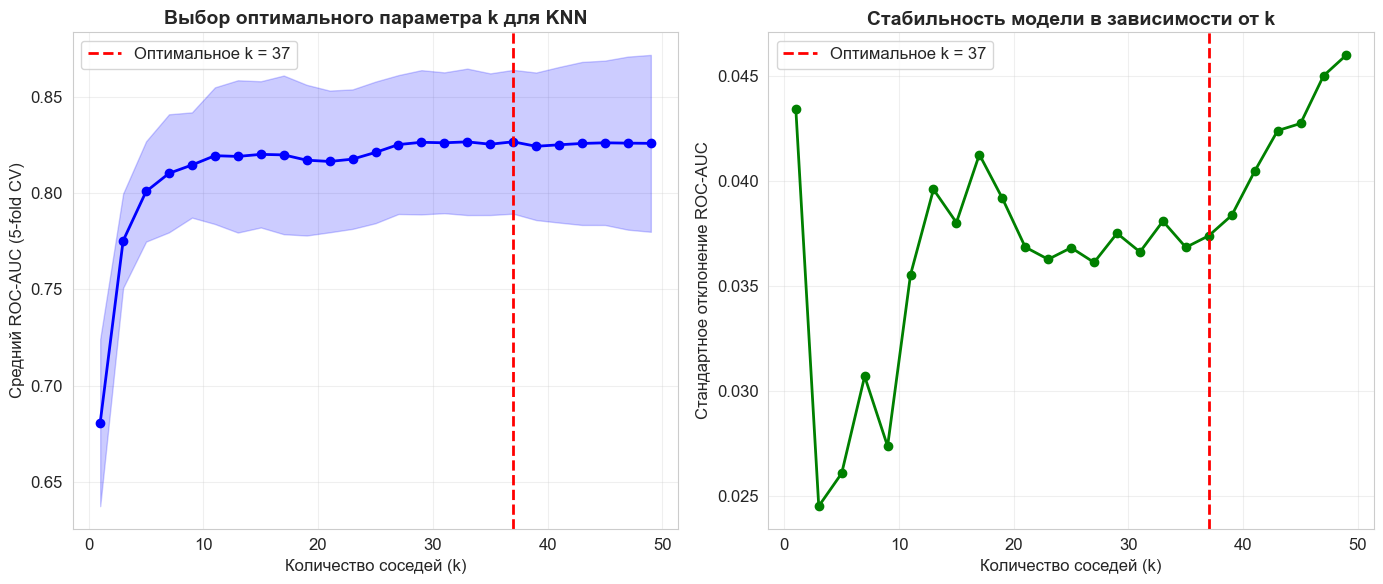

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(k_values, cv_scores_mean, 'bo-', linewidth=2, markersize=6)
axes[0].fill_between(k_values, 
                      np.array(cv_scores_mean) - np.array(cv_scores_std),
                      np.array(cv_scores_mean) + np.array(cv_scores_std),
                      alpha=0.2, color='blue')
axes[0].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Оптимальное k = {best_k}')
axes[0].set_xlabel('Количество соседей (k)', fontsize=12)
axes[0].set_ylabel('Средний ROC-AUC (5-fold CV)', fontsize=12)
axes[0].set_title('Выбор оптимального параметра k для KNN', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, cv_scores_std, 'go-', linewidth=2, markersize=6)
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Оптимальное k = {best_k}')
axes[1].set_xlabel('Количество соседей (k)', fontsize=12)
axes[1].set_ylabel('Стандартное отклонение ROC-AUC', fontsize=12)
axes[1].set_title('Стабильность модели в зависимости от k', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

При низких k (1-5) низкое смещение, высокая дисперсия - происходит переобучение, модель ловит шум.

При больших k противоположная динамика, модель оказывается недообученной.

Сбалансированное значение k = 37. Используем это значение для обучения модели KNN.

In [126]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_train_pred_knn = knn_final.predict(X_train_scaled)
y_test_pred_knn = knn_final.predict(X_test_scaled)
y_train_proba_knn = knn_final.predict_proba(X_train_scaled)[:, 1]
y_test_proba_knn = knn_final.predict_proba(X_test_scaled)[:, 1]

Оценим качество модели.

In [171]:
knn_metrics_train = {
    'Accuracy': accuracy_score(y_train, y_train_pred_knn),
    'Precision': precision_score(y_train, y_train_pred_knn),
    'Recall': recall_score(y_train, y_train_pred_knn),
    'F1-score': f1_score(y_train, y_train_pred_knn),
    'ROC-AUC': roc_auc_score(y_train, y_train_proba_knn)
}

knn_metrics_test = {
    'Accuracy': accuracy_score(y_test, y_test_pred_knn),
    'Precision': precision_score(y_test, y_test_pred_knn),
    'Recall': recall_score(y_test, y_test_pred_knn),
    'F1-score': f1_score(y_test, y_test_pred_knn),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_knn)
}

print("\n Метрики качества модели KNN ")
print(" " * 90)
print(f"{'Метрика':<12} {'Обучающая выборка':<20} {'Тестовая выборка':<20} {'Разница':<10}")
print(" " * 90)

for metric in knn_metrics_train.keys():
    train_val = knn_metrics_train[metric]
    test_val = knn_metrics_test[metric]
    diff = abs(train_val - test_val)
    print(f"{metric:<12} {train_val:<20.4f} {test_val:<20.4f} {diff:<10.4f}")

print(" " * 90)


 Метрики качества модели KNN 
                                                                                          
Метрика      Обучающая выборка    Тестовая выборка     Разница   
                                                                                          
Accuracy     0.7987               0.7640               0.0347    
Precision    0.8456               0.8022               0.0434    
Recall       0.8605               0.8639               0.0034    
F1-score     0.8530               0.8319               0.0211    
ROC-AUC      0.8434               0.7911               0.0523    
                                                                                          


Модель незначительно переобучена - показывает лучше результаты на обучающей выборке, чем на тестовой. Моедли будет сложнее различать классы на новых данных и будет незначительно больше срабатываний на новых клиентах.

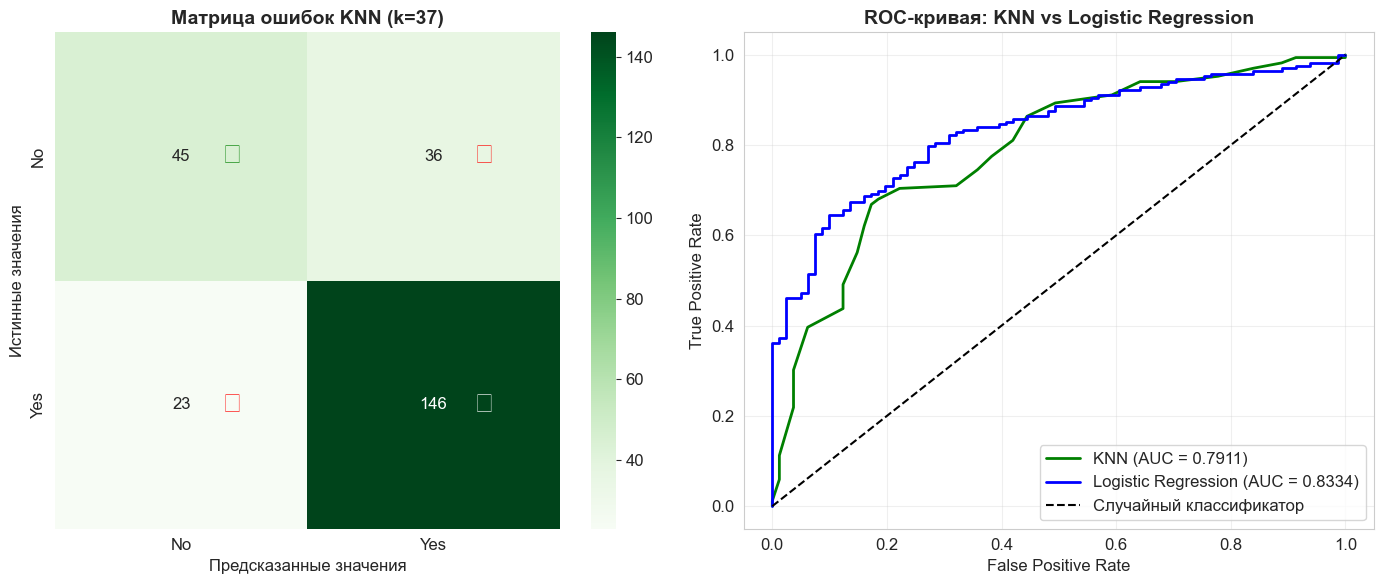

In [131]:
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'Матрица ошибок KNN (k={best_k})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Предсказанные значения', fontsize=12)
axes[0].set_ylabel('Истинные значения', fontsize=12)

for i in range(2):
    for j in range(2):
        if i == j:
            axes[0].text(j+0.7, i+0.5, '✓', ha='center', va='center', fontsize=20, 
                        color='white' if cm_knn[i,j] > cm_knn.max()/2 else 'green')
        else:
            axes[0].text(j+0.7, i+0.5, '✗', ha='center', va='center', fontsize=20, color='red')

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_test_proba_knn)
roc_auc_knn = knn_metrics_test['ROC-AUC']

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba)

axes[1].plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})', linewidth=2, color='green')
axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {test_metrics["ROC-AUC"]:.4f})', linewidth=2, color='blue')
axes[1].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор', linewidth=1.5)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC-кривая: KNN vs Logistic Regression', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модель работает хуже, чем логистическая регрессия.
Модель чаще улавливает ложные позитивные сигналы - то есть приписывает использование услуги клиентам, которые ей не пользуются.

Для оценки важности признаков в модели используем:
1. Метод перестановки (Permutation Importance)
2. Анализ влияния признаков на расстояние

In [170]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    knn_final, X_test_scaled, y_test, 
    n_repeats=10, random_state=42, scoring='roc_auc'
)

feature_importance_knn = pd.DataFrame({
    'Признак': feature_names,
    'Важность (ΔROC-AUC)': perm_importance.importances_mean,
    'Стандартное отклонение': perm_importance.importances_std
}).sort_values('Важность (ΔROC-AUC)', ascending=False)

print("\n Важность признаков (снижение ROC-AUC при перемешивании) ")
print(" " * 90)
print(feature_importance_knn.to_string(index=False))
print(" " * 90)


 Важность признаков (снижение ROC-AUC при перемешивании) 
                                                                                          
         Признак  Важность (ΔROC-AUC)  Стандартное отклонение
          tenure             0.162108                0.031227
wireless_encoded             0.080809                0.018401
             age             0.026302                0.013836
          income             0.001461                0.002702
  retire_encoded             0.000391                0.007739
   region_Zone 3            -0.003715                0.006584
   region_Zone 2            -0.003850                0.005910
          reside            -0.004259                0.007070
  gender_encoded            -0.005892                0.008277
                                                                                          


В этой модели, как и в логистической регрессии, основными влияющими признаками стали:
1. Срок использования клиентом услуг компании
2. Использование беспроводной сети
3. Возраст клиента

### Построим дерево решений в оптимизированной форме. 
Подберем минимальную оптимальную глубину.

Оптимальная глубина: 4


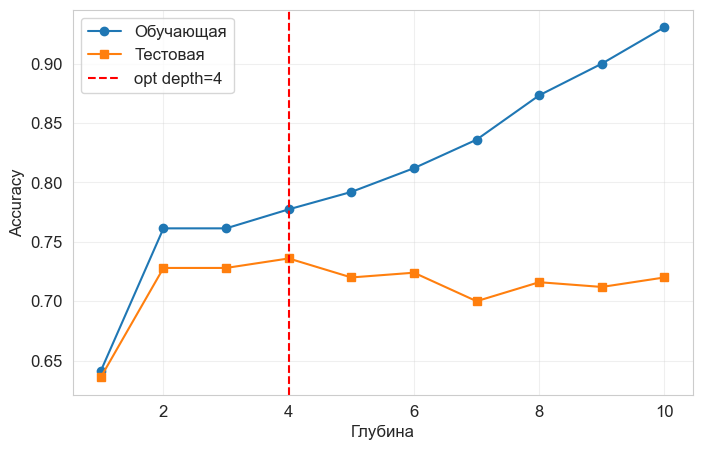

In [136]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

depths = range(1, 11)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test_scaled)))

best_depth = depths[np.argmax(test_scores)]
print(f"Оптимальная глубина: {best_depth}")

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, 'o-', label='Обучающая')
plt.plot(depths, test_scores, 's-', label='Тестовая')
plt.axvline(best_depth, color='r', linestyle='--', label=f'opt depth={best_depth}')
plt.xlabel('Глубина')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


 Метрики дерева решений 
                                                                                          
  Accuracy: 0.7360
  Precision: 0.8759
  Recall: 0.7101
  F1-score: 0.7843
  ROC-AUC: 0.8100


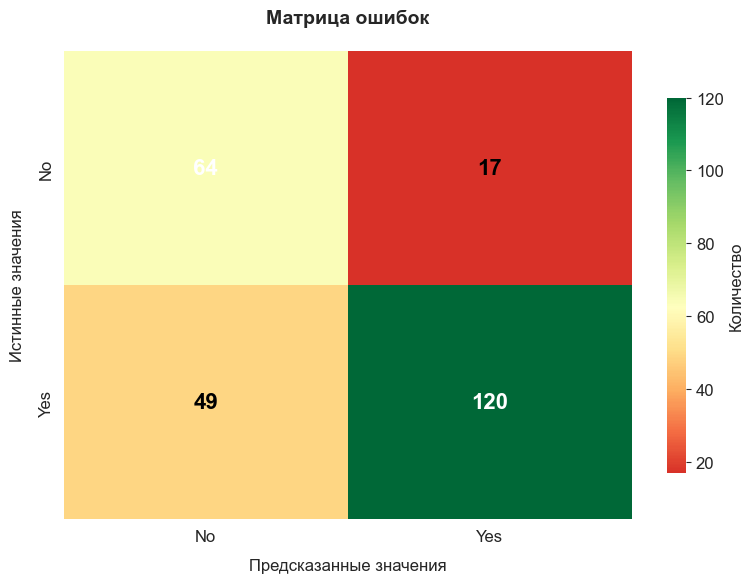

In [169]:
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42, class_weight='balanced')
dt_final.fit(X_train_scaled, y_train)

y_test_pred_dt = dt_final.predict(X_test_scaled)
y_test_proba_dt = dt_final.predict_proba(X_test_scaled)[:, 1]

print("\n Метрики дерева решений ")
print(" " * 90)
dt_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred_dt),
    'Precision': precision_score(y_test, y_test_pred_dt),
    'Recall': recall_score(y_test, y_test_pred_dt),
    'F1-score': f1_score(y_test, y_test_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_dt)
}

for m, v in dt_metrics.items():
    print(f"  {m}: {v:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))

cm_custom = cm_dt.copy()
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='RdYlGn', center=cm_custom.mean(), 
            ax=ax, xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar_kws={"shrink": 0.8, "label": "Количество"})

ax.set_title('Матрица ошибок', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Предсказанные значения', fontsize=12, labelpad=10)
ax.set_ylabel('Истинные значения', fontsize=12, labelpad=10)

for i in range(2):
    for j in range(2):
        text = ax.texts[i*2 + j]
        if cm_custom[i, j] > cm_custom.max() / 2:
            text.set_color('white')
        else:
            text.set_color('black')

plt.tight_layout()
plt.show()

Модель дает около 74% верных ответов, в 88% ее предложения верны.
ROC-AUC указывает на достаточное качество предсказаний модели. 

Модель работает лучше KNN, но хуже логистической регрессии.

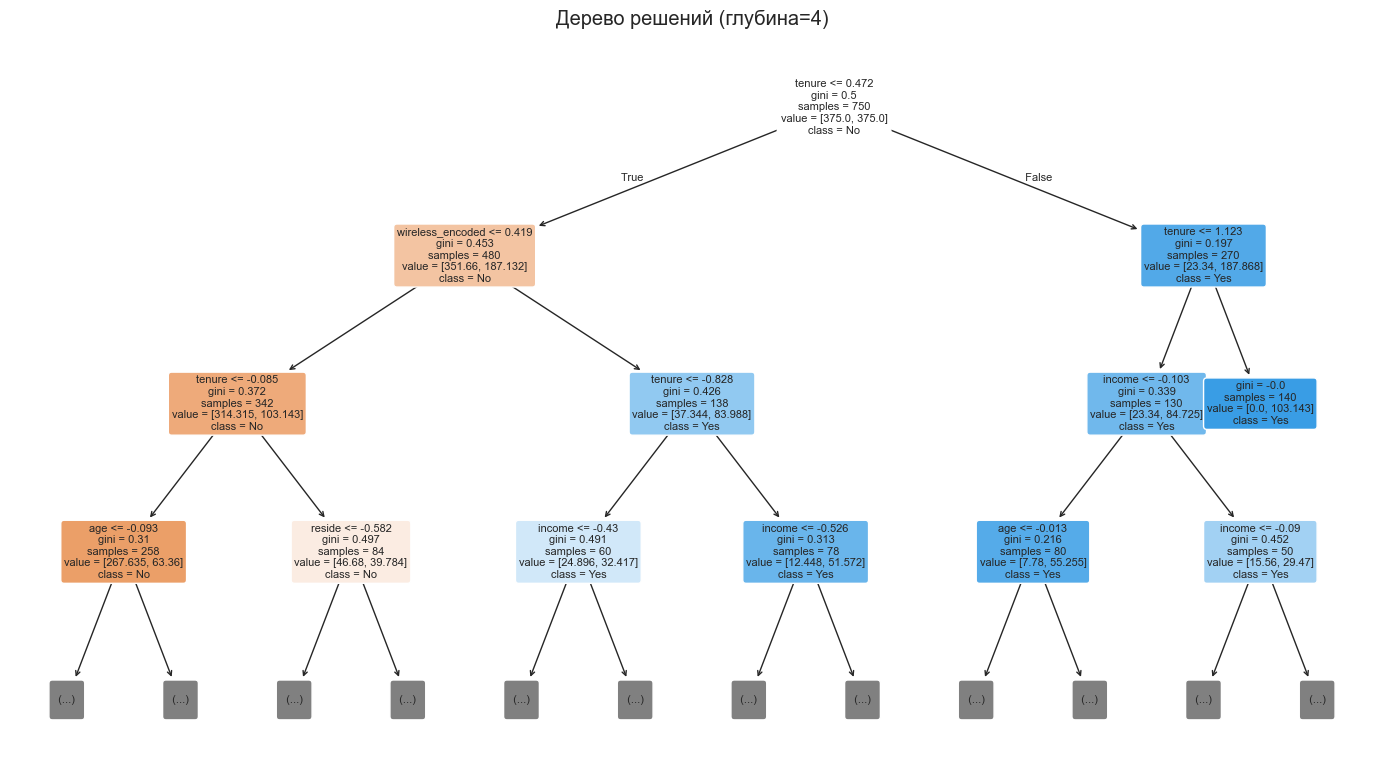

In [141]:
plt.figure(figsize=(14, 8))
plot_tree(dt_final, feature_names=feature_names, class_names=['No', 'Yes'], 
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title(f'Дерево решений (глубина={best_depth})')
plt.tight_layout()
plt.show()

Проанализируем важность признаков модели.


 Важность признаков 
                                                                                          
         Признак  Важность
          tenure  0.656825
wireless_encoded  0.227616
          income  0.069033
             age  0.034511
          reside  0.012015
  retire_encoded  0.000000
  gender_encoded  0.000000
   region_Zone 2  0.000000
   region_Zone 3  0.000000


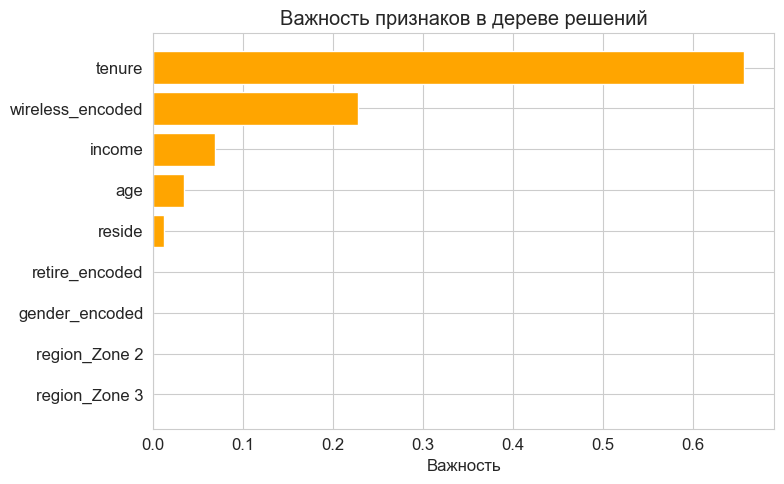

In [167]:
importance_dt = pd.DataFrame({
    'Признак': feature_names,
    'Важность': dt_final.feature_importances_
}).sort_values('Важность', ascending=False)

print("\n Важность признаков ")
print(" " * 90)
print(importance_dt.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_dt['Признак'], importance_dt['Важность'], color='orange')
plt.xlabel('Важность')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

В этой модели выжными признаками стали стаж использования услуг компании, использование беспроводной сети и доход. 

### Построим модель случайный лес. 

Гиперпараметры для модели:
- n_estimators=100: для сохранения баланса качество/скорость
- max_depth=5-10: предотвращает переобучение
- min_samples_split=5: требует минимум 5 образцов для разделения

In [166]:
from sklearn.ensemble import RandomForestClassifier

print("\n Подбор гиперпараметров (сокращенный) ")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 7, 10],
    'min_samples_split': [5, 10]
}

from sklearn.model_selection import GridSearchCV

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_search = GridSearchCV(rf_base, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC на CV: {grid_search.best_score_:.4f}")

rf_best = grid_search.best_estimator_


 Подбор гиперпараметров (сокращенный) 
Лучшие параметры: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Лучший ROC-AUC на CV: 0.8357


Теперь оценим параметры модели.

In [165]:
y_train_pred_rf = rf_best.predict(X_train_scaled)
y_test_pred_rf = rf_best.predict(X_test_scaled)
y_test_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred_rf),
    'Precision': precision_score(y_test, y_test_pred_rf),
    'Recall': recall_score(y_test, y_test_pred_rf),
    'F1-score': f1_score(y_test, y_test_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_rf)
}

print("\n Метрики на тестовой выборке ")
print(" " * 90)
for m, v in rf_metrics.items():
    print(f"  {m}: {v:.4f}")

train_accuracy = accuracy_score(y_train, y_train_pred_rf)
train_roc_auc = roc_auc_score(y_train, rf_best.predict_proba(X_train_scaled)[:, 1])
print(f"\nОбучающая выборка: Accuracy={train_accuracy:.4f}, ROC-AUC={train_roc_auc:.4f}")
print(f"Разница train-test по ROC-AUC: {train_roc_auc - rf_metrics['ROC-AUC']:.4f}")


 Метрики на тестовой выборке 
                                                                                          
  Accuracy: 0.7520
  Precision: 0.8741
  Recall: 0.7396
  F1-score: 0.8013
  ROC-AUC: 0.8365

Обучающая выборка: Accuracy=0.8120, ROC-AUC=0.8994
Разница train-test по ROC-AUC: 0.0629


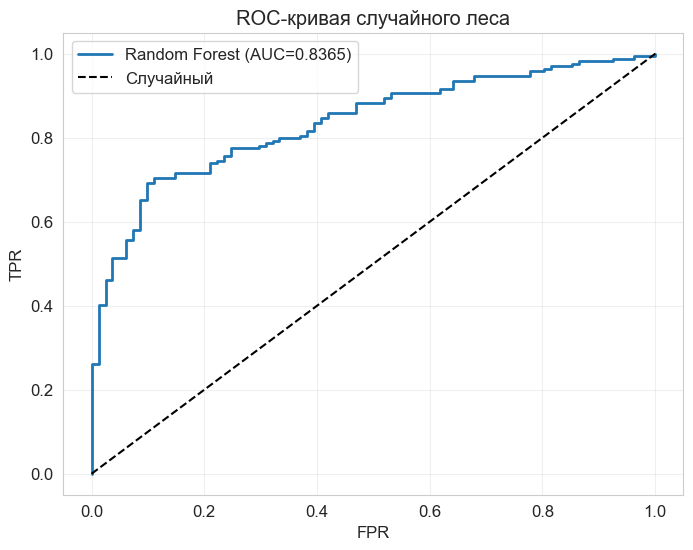

In [163]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_metrics["ROC-AUC"]:.4f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Случайный')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривая случайного леса')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Модель дает около 75% верных ответов, в 87% случаев ее предложения точны. ROC-AUC хороший, на уровне с остальными моделями. Есть незначительная разница между ROC-AUC на test/train (6%), но она не критичная.

Исследуем важность признаков в модели.


 Важность признаков (Random Forest) 
                                                                                          
         Признак  Важность
          tenure  0.556842
wireless_encoded  0.175889
             age  0.126226
          income  0.076644
          reside  0.031549
  gender_encoded  0.010148
   region_Zone 2  0.009110
   region_Zone 3  0.007109
  retire_encoded  0.006482


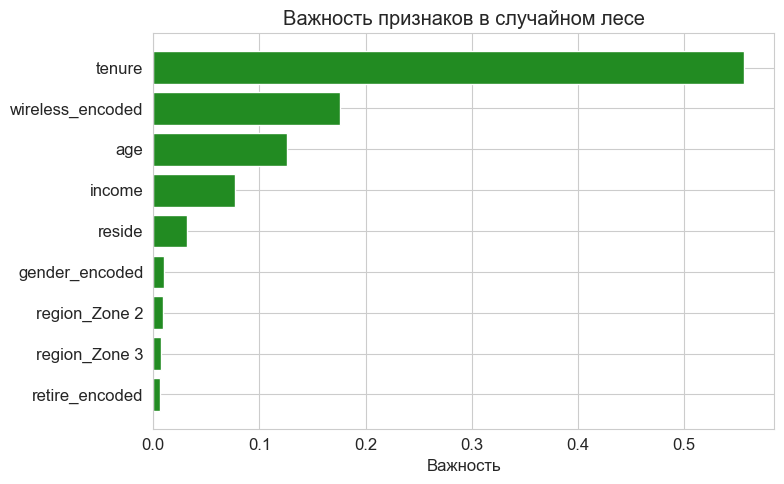

In [162]:
importance_rf = pd.DataFrame({
    'Признак': feature_names,
    'Важность': rf_best.feature_importances_
}).sort_values('Важность', ascending=False)

print("\n Важность признаков (Random Forest) ")
print(" " * 90)
print(importance_rf.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_rf['Признак'], importance_rf['Важность'], color='forestgreen')
plt.xlabel('Важность')
plt.title('Важность признаков в случайном лесе')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Основные важные признаки для прогнозов: стаж пользования клиентом услугами компании (как и во всех остальных моделях), использование беспроводной сети (все, кроме логистической регрессии) и возраст клиента (как в логистической регрессии). 

Теперь сравним между собой работу всех моделей.


 Сравнение метрик по моделям 
                                                                                          
             Модель  Accuracy  Precision   Recall  F1-score  ROC-AUC
Logistic Regression     0.736   0.875912 0.710059  0.784314 0.833443
                KNN     0.764   0.802198 0.863905  0.831909 0.791073
      Decision Tree     0.736   0.875912 0.710059  0.784314 0.810030
      Random Forest     0.752   0.874126 0.739645  0.801282 0.836511
                                                                                          


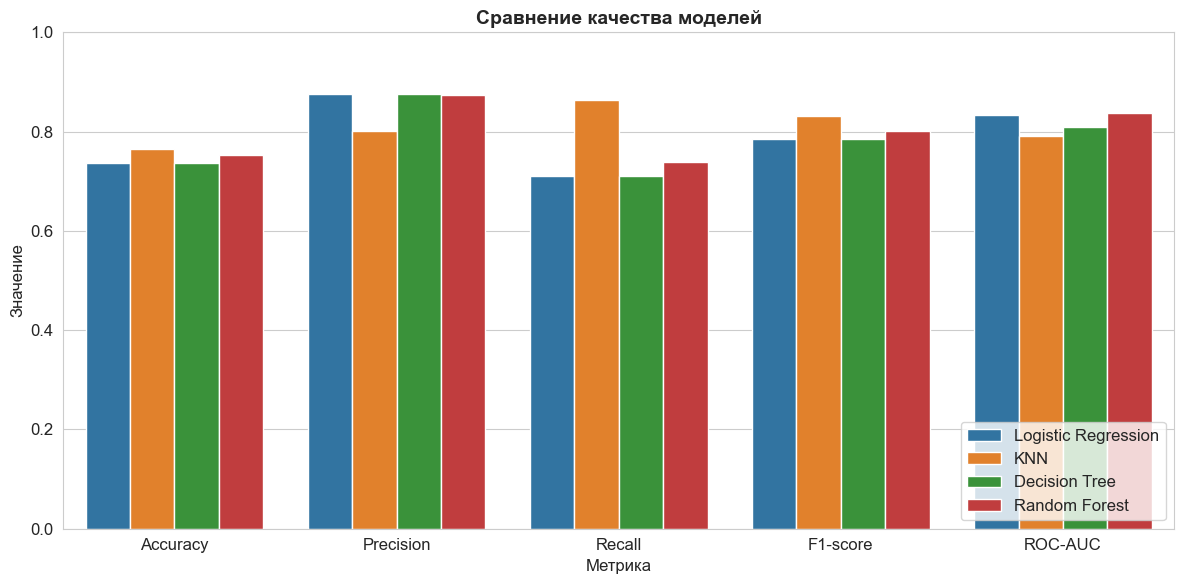

In [159]:
models_comparison = pd.DataFrame({
    'Модель': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        test_metrics['Accuracy'],
        knn_metrics_test['Accuracy'],
        dt_metrics['Accuracy'],
        rf_metrics['Accuracy']
    ],
    'Precision': [
        test_metrics['Precision'],
        knn_metrics_test['Precision'],
        dt_metrics['Precision'],
        rf_metrics['Precision']
    ],
    'Recall': [
        test_metrics['Recall'],
        knn_metrics_test['Recall'],
        dt_metrics['Recall'],
        rf_metrics['Recall']
    ],
    'F1-score': [
        test_metrics['F1-score'],
        knn_metrics_test['F1-score'],
        dt_metrics['F1-score'],
        rf_metrics['F1-score']
    ],
    'ROC-AUC': [
        test_metrics['ROC-AUC'],
        knn_metrics_test['ROC-AUC'],
        dt_metrics['ROC-AUC'],
        rf_metrics['ROC-AUC']
    ]
})

print("\n Сравнение метрик по моделям ")
print(" " * 90)
print(models_comparison.to_string(index=False))
print(" " * 90)

fig, ax = plt.subplots(figsize=(12, 6))
models_comparison_melted = models_comparison.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')
sns.barplot(data=models_comparison_melted, x='Метрика', y='Значение', hue='Модель', ax=ax)
ax.set_title('Сравнение качества моделей', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

У случайного леса наиболее высокий показатель ROC-AUC и точность предсказаний.
Верности предказаний на том же уровне в модели логистической регрессии, при этом ее ROC-AUC незначительно ниже.


В точности предсказаний и по recall, F-1 лучше работает KNN.
Модель дерево решений сильна только в точности предсказаний.

Лучшая модель - случайный лес, она выигрывает по общему лучшему качеству.

In [158]:
importance_dict = {}

lr_importance_abs = np.abs(lr_l2.coef_[0])
importance_dict['LogReg'] = pd.Series(lr_importance_abs, index=feature_names)

importance_dict['KNN'] = pd.Series(feature_importance_knn['Важность (ΔROC-AUC)'].values, index=feature_names)

importance_dict['Decision Tree'] = pd.Series(dt_final.feature_importances_, index=feature_names)

importance_dict['Random Forest'] = pd.Series(rf_best.feature_importances_, index=feature_names)

importance_df = pd.DataFrame(importance_dict)
importance_df = importance_df.round(4)

print("\n Сравнение важности признаков по моделям ")
print(" " * 80)
print(importance_df.to_string())

importance_norm = importance_df.div(importance_df.sum(axis=0), axis=1)


 Сравнение важности признаков по моделям 
                                                                                
                  LogReg     KNN  Decision Tree  Random Forest
reside            0.1082  0.1621         0.0120         0.0315
age               0.2156  0.0808         0.0345         0.1262
tenure            1.0054  0.0263         0.6568         0.5568
income            0.0042  0.0015         0.0690         0.0766
retire_encoded    0.1260  0.0004         0.0000         0.0065
gender_encoded    0.0005 -0.0037         0.0000         0.0101
wireless_encoded  0.6572 -0.0038         0.2276         0.1759
region_Zone 2     0.0244 -0.0043         0.0000         0.0091
region_Zone 3     0.0345 -0.0059         0.0000         0.0071


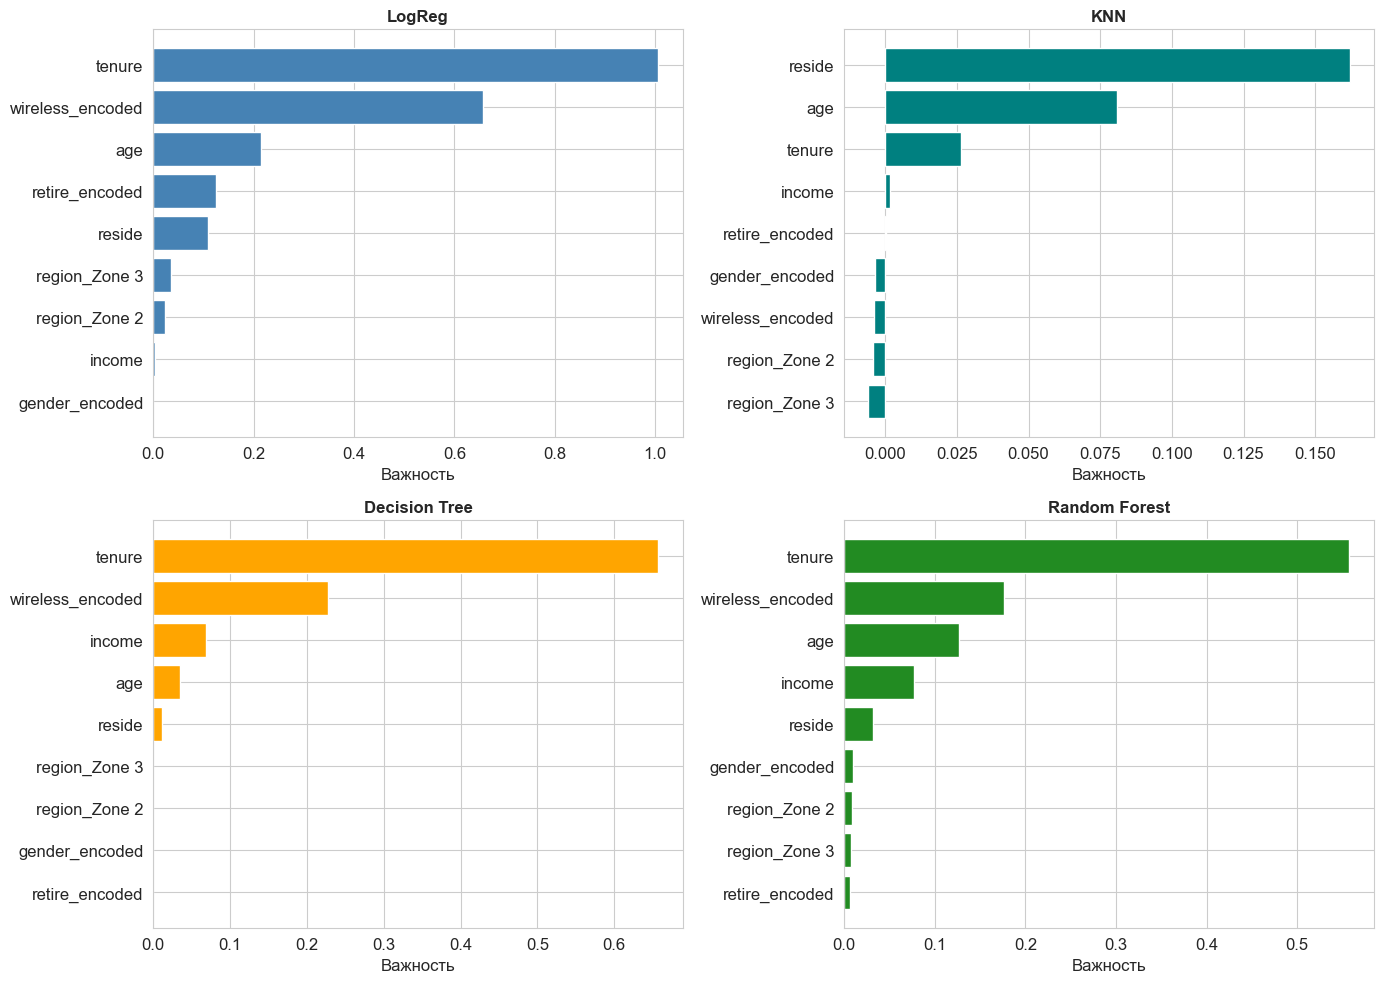

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, model in enumerate(importance_df.columns):
    imp_sorted = importance_df[model].sort_values(ascending=True)
    axes[i].barh(imp_sorted.index, imp_sorted.values, color=['steelblue', 'teal', 'orange', 'forestgreen'][i])
    axes[i].set_title(f'{model}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Важность')
    
plt.tight_layout()
plt.show()

ТОП признаков по всем моделям: 

1. стаж использования услуг компании.

2. использование беспроводного интернета пользователем.

3. возраст пользователя.